In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# Load dataset
df = pd.read_excel(r"C:\Users\Atharva More\Downloads\online_retail_II.xlsx",
                   sheet_name='Year 2010-2011')

# Clean
df_clean = df.dropna(subset=['Customer ID'])
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# RFM Features
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']
rfm['RecencyScore'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1]).astype(int)
rfm['FrequencyScore'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['MonetaryScore'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['RFMScore'] = rfm['RecencyScore'] + rfm['FrequencyScore'] + rfm['MonetaryScore']
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

features = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
            'RecencyScore', 'FrequencyScore', 'MonetaryScore', 'RFMScore']

X = rfm[features]
y = rfm['Churn']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train XGBoost
model = xgb.XGBClassifier(n_estimators=200, max_depth=6,
                           learning_rate=0.05, random_state=42,
                           verbosity=0)
model.fit(X_train, y_train)

print("✅ Data ready & model trained!")

✅ Data ready & model trained!


In [3]:
# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values calculated!")
print(f"📊 Shape of SHAP values: {shap_values.shape}")

✅ SHAP values calculated!
📊 Shape of SHAP values: (868, 8)


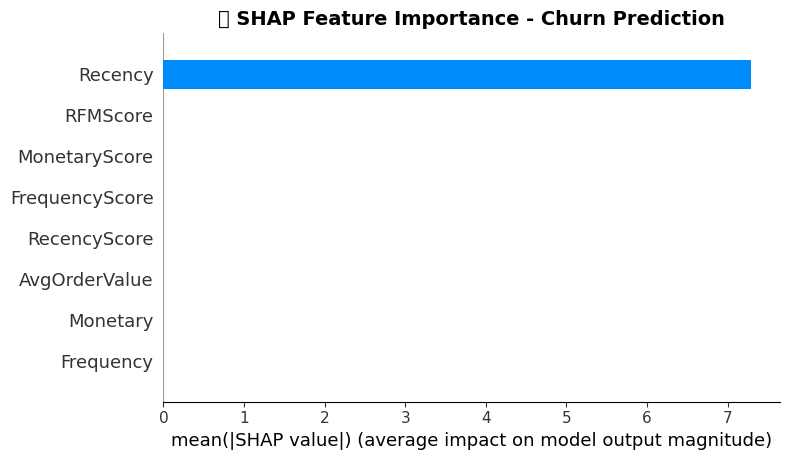

✅ SHAP summary plot saved!


In [4]:
# SHAP Summary Plot - shows most important features
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('🔍 SHAP Feature Importance - Churn Prediction', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\shap_summary.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved!")

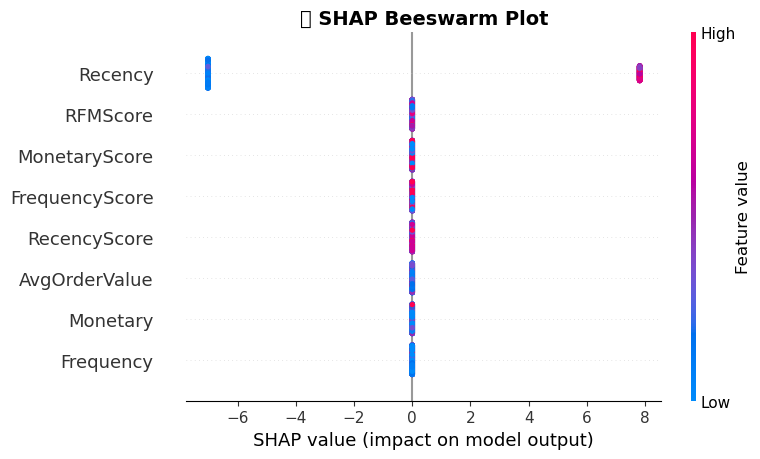

✅ SHAP beeswarm plot saved!


In [5]:
# Beeswarm plot - shows impact of each feature
shap.summary_plot(shap_values, X_test, show=False)
plt.title('🔍 SHAP Beeswarm Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\shap_beeswarm.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP beeswarm plot saved!")

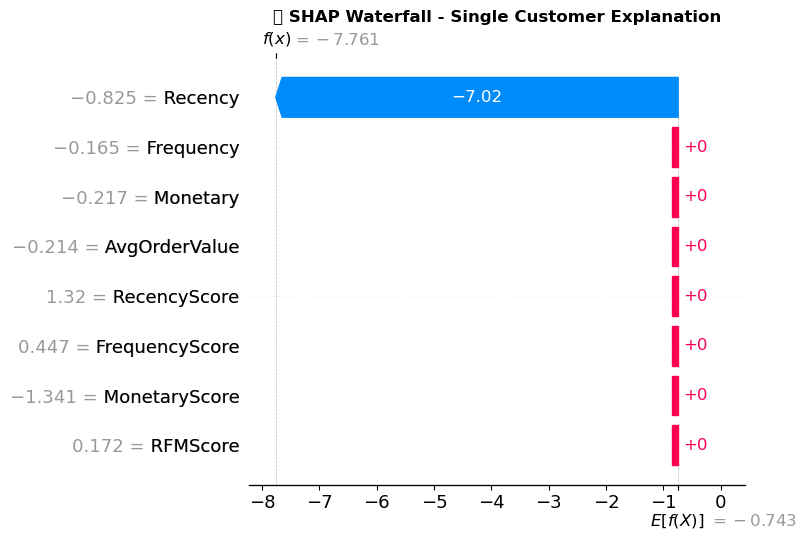

✅ SHAP waterfall plot saved!


In [6]:
# Waterfall plot for single customer prediction
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0],
    feature_names=features), show=False)
plt.title('🔍 SHAP Waterfall - Single Customer Explanation', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\Atharva More\NeuralRetail\reports\shap_waterfall.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP waterfall plot saved!")

In [7]:
# Get top features by mean SHAP value
shap_importance = pd.DataFrame({
    'Feature': features,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print("=" * 55)
print("🔍 SHAP EXPLAINABILITY INSIGHTS")
print("=" * 55)
print("\n📊 Top Features Driving Churn:")
for _, row in shap_importance.iterrows():
    print(f"   {row['Feature']}: {row['Mean_SHAP']:.4f}")
print()
print("💡 Business Actions:")
print("   → High Recency = Customer hasn't bought recently → Send win-back email")
print("   → Low Frequency = Customer rarely buys → Offer loyalty rewards")
print("   → Low Monetary = Low spend customer → Upsell premium products")
print("   → Low RFM Score = Overall disengaged → Priority retention campaign")
print("=" * 55)
print("✅ Day 11 - SHAP Explainability Complete!")
print("=" * 55)

🔍 SHAP EXPLAINABILITY INSIGHTS

📊 Top Features Driving Churn:
   Recency: 7.2846
   Frequency: 0.0000
   Monetary: 0.0000
   AvgOrderValue: 0.0000
   RecencyScore: 0.0000
   FrequencyScore: 0.0000
   MonetaryScore: 0.0000
   RFMScore: 0.0000

💡 Business Actions:
   → High Recency = Customer hasn't bought recently → Send win-back email
   → Low Frequency = Customer rarely buys → Offer loyalty rewards
   → Low Monetary = Low spend customer → Upsell premium products
   → Low RFM Score = Overall disengaged → Priority retention campaign
✅ Day 11 - SHAP Explainability Complete!
